# 5.2 — Bootstrapping de curva única

5.1 dejó los instrumentos y sus fórmulas de tasa par; ahora hay que resolver el problema inverso: **dado** un puñado de cotizaciones de mercado (depósitos cortos, swaps largos, todos a la par por definición de cotización), encontrar la curva de descuento $P(0,t)$ que los reprecia **exactamente**. Es el mismo tipo de problema que 4.4 resolvió con regresión y 3.4 con un árbol — encontrar un objeto continuo (aquí, una función de descuento) a partir de restricciones discretas — pero aquí la estructura del problema permite algo mucho más simple que optimizar: un algoritmo **secuencial** y exacto, sin resolver ningún sistema ni minimizar nada.

Este notebook construye ese algoritmo desde cero, lo valida reproduciendo una curva "verdadera" sintética, y promueve el resultado a `qflib.curves.DiscountCurve` — el objeto que M6 y M7 van a usar como dato de entrada sin volver a pensar en bootstrapping.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import QuantLib as ql

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()

print(f"Curva verdadera: Nelson-Siegel con parametros por defecto")
print(f"P(0,1) = {nelson_siegel_df(1.0):.6f}  |  P(0,5) = {nelson_siegel_df(5.0):.6f}  |  "
      f"P(0,10) = {nelson_siegel_df(10.0):.6f}")
print("Sin Monte Carlo -- bootstrapping es aritmetica secuencial exacta.")

Curva verdadera: Nelson-Siegel con parametros por defecto
P(0,1) = 0.961814  |  P(0,5) = 0.801800  |  P(0,10) = 0.638058
Sin Monte Carlo -- bootstrapping es aritmetica secuencial exacta.


## 1. El algoritmo de bootstrapping secuencial

**Depósitos** fijan los primeros nodos directamente: de $L(0,t)$ cotizada, $P(0,t)=\dfrac{1}{1+L(0,t)\,t}$ — no hay nada que resolver, es la definición misma de tasa simple.

**Swaps**, uno a la vez en orden creciente de vencimiento. La ecuación de la tasa par de un swap a $n$ años (5.1 §4),
$$
K_n = \frac{1-P(0,T_n)}{\sum_{i=1}^n\tau_iP(0,T_i)},
$$
tiene **una sola incógnita** si ya se conocen $P(0,T_1),\dots,P(0,T_{n-1})$ de los swaps anteriores: despejando,
$$
\sum_{i=1}^{n-1}\tau_iP(0,T_i) + \tau_nP(0,T_n) = \frac{1-P(0,T_n)}{K_n}
\quad\Longrightarrow\quad
\boxed{P(0,T_n) = \frac{1-K_n\sum_{i=1}^{n-1}\tau_iP(0,T_i)}{1+K_n\tau_n}}.
$$
Cada swap sucesivo añade exactamente un nodo nuevo, en forma cerrada, sin optimización — el bootstrapping es una recursión, no un ajuste. El precio de esa simplicidad: **entre** nodos hace falta interpolar, y la elección de interpolador (aquí, log-lineal en discount factor: $\ln P(0,t)$ lineal a trozos entre nodos consecutivos) sí introduce una aproximación real, que 5.4 va a diseccionar en detalle.

**Una sutileza que 5.1 ya advirtió y que aquí se vuelve numérica de verdad:** los "años" de un swap no son fracciones nominales exactas. Un swap a $n$ años vencido el $n$-ésimo aniversario calendario de hoy cubre $n\cdot365+(\text{días bisiestos en el camino})$ días, así que su fracción `Act/365 Fixed` es ligeramente mayor que $n$ exacto. Ignorar esto (usar $\tau_i=1$ nominal siempre) produce un error sistemático de bootstrapping del orden de $10^{-5}$ en discount factor — pequeño, pero **no** es ruido numérico, es un error de convención, y por eso este notebook usa fechas reales de principio a fin en vez de años nominales.

In [2]:
def bootstrap_curve(deposit_periods, deposit_rates, swap_tenors_years, swap_rates, eval_date, day_count):
    '''Sequential bootstrapping (Section 1): deposits fix nodes directly, swaps solve one node
    each in closed form given all earlier nodes. Returns (times, discount_factors) using REAL
    calendar dates (not nominal integer years) for every year fraction.'''
    times, dfs = [], []

    for period, L in zip(deposit_periods, deposit_rates):
        t = day_count.yearFraction(eval_date, eval_date + period)
        times.append(t)
        dfs.append(1.0 / (1.0 + L * t))

    swap_dates = [eval_date + ql.Period(n, ql.Years) for n in swap_tenors_years]
    swap_times = [day_count.yearFraction(eval_date, d) for d in swap_dates]
    known_swap_times, known_swap_dfs = [], []
    for K, t_n in zip(swap_rates, swap_times):
        prev_times = np.array([0.0] + known_swap_times)
        prev_dfs = np.array(known_swap_dfs)
        tau_known = np.diff(prev_times)
        sum_known = np.sum(tau_known * prev_dfs) if len(prev_dfs) else 0.0
        tau_n = t_n - (known_swap_times[-1] if known_swap_times else 0.0)
        df_n = (1.0 - K * sum_known) / (1.0 + K * tau_n)
        known_swap_times.append(t_n)
        known_swap_dfs.append(df_n)

    times.extend(known_swap_times)
    dfs.extend(known_swap_dfs)
    return np.array(times), np.array(dfs)


# --- cotizaciones sinteticas: evaluar la curva verdadera en fechas REALES ---
deposit_periods = [ql.Period(1, ql.Months), ql.Period(3, ql.Months), ql.Period(6, ql.Months)]
deposit_times_true = [day_count.yearFraction(eval_date, eval_date + p) for p in deposit_periods]
deposit_dfs_true = [nelson_siegel_df(t) for t in deposit_times_true]
deposit_rates = [(1.0 / df - 1.0) / t for df, t in zip(deposit_dfs_true, deposit_times_true)]

swap_tenors = list(range(1, 11))
swap_dates_true = [eval_date + ql.Period(n, ql.Years) for n in swap_tenors]
swap_times_true = [day_count.yearFraction(eval_date, d) for d in swap_dates_true]
swap_rates = [par_swap_rate(nelson_siegel_df, np.array(swap_times_true[:n])) for n in range(1, len(swap_tenors) + 1)]

print("Cotizaciones sinteticas:")
for p, L in zip(deposit_periods, deposit_rates):
    print(f"  deposito {p}: L = {L:.6%}")
for n, K in zip(swap_tenors, swap_rates):
    print(f"  swap {n}Y: K = {K:.6%}")

Cotizaciones sinteticas:
  deposito 1M: L = 3.546908%
  deposito 3M: L = 3.634960%
  deposito 6M: L = 3.757950%
  swap 1Y: K = 3.970258%
  swap 2Y: K = 4.214181%
  swap 3Y: K = 4.360009%
  swap 4Y: K = 4.447815%
  swap 5Y: K = 4.500943%
  swap 6Y: K = 4.533429%
  swap 7Y: K = 4.553318%
  swap 8Y: K = 4.565718%
  swap 9Y: K = 4.573584%
  swap 10Y: K = 4.578719%


## 2. Demo 1 — bootstrapping vs la curva verdadera

Con las cotizaciones sintéticas, corremos el bootstrap y comparamos contra la curva Nelson-Siegel que las generó. En los nodos, la coincidencia debe ser exacta (es la definición del algoritmo); entre nodos, la interpolación log-lineal introduce un error real que dependerá de cuánta curvatura tenga la curva verdadera entre esos puntos — visible sobre todo en el tramo corto, donde la curva Nelson-Siegel tiene más forma por unidad de tiempo.

         t |  df bootstrap |  df verdadero |       diff
------------------------------------------------------
  0.084932 |    0.99699660 |    0.99699660 |  -1.11e-16
  0.252055 |    0.99092109 |    0.99092109 |  -1.11e-16
  0.504110 |    0.98140802 |    0.98140802 |  -1.11e-16
  1.000000 |    0.96181352 |    0.96181352 |   0.00e+00
  2.002740 |    0.92056681 |    0.92056681 |  -1.11e-16
  3.002740 |    0.87947298 |    0.87947298 |  -1.11e-16
  4.002740 |    0.83969749 |    0.83969749 |   0.00e+00
  5.002740 |    0.80169871 |    0.80169871 |   0.00e+00
  6.005479 |    0.76547035 |    0.76547035 |   1.11e-16
  7.005479 |    0.73114982 |    0.73114982 |   0.00e+00
  8.005479 |    0.69852498 |    0.69852498 |  -1.11e-16
  9.005479 |    0.66747797 |    0.66747797 |   1.11e-16
 10.008219 |    0.63782057 |    0.63782057 |   0.00e+00


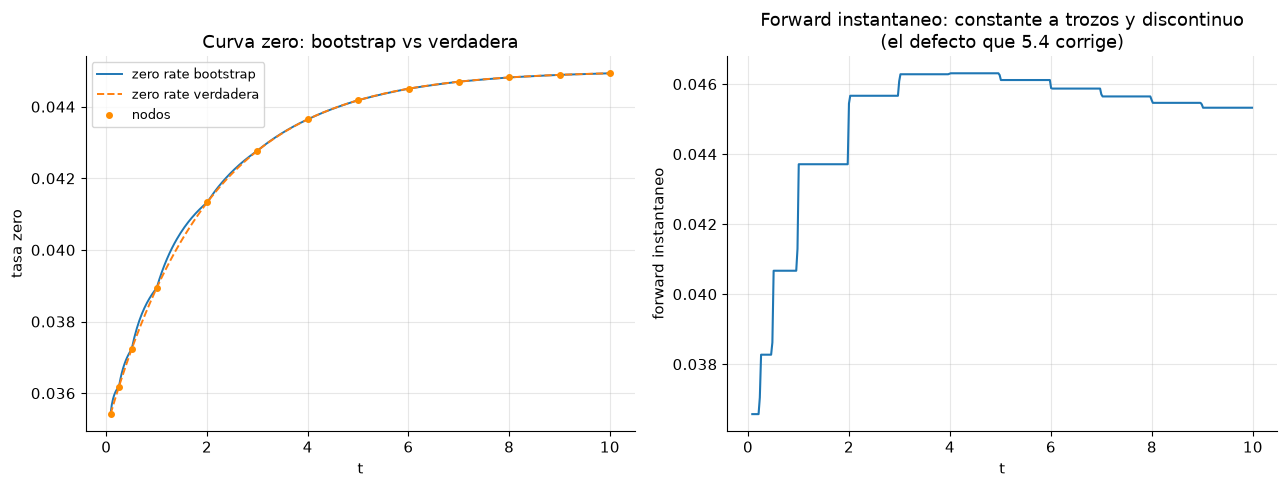

In [3]:
times, dfs = bootstrap_curve(deposit_periods, deposit_rates, swap_tenors, swap_rates, eval_date, day_count)

from qflib.curves import DiscountCurve

curve = DiscountCurve(times, dfs)

print(f"{'t':>10} | {'df bootstrap':>13} | {'df verdadero':>13} | {'diff':>10}")
print("-" * 54)
for t, df in zip(times, dfs):
    true_df = nelson_siegel_df(t)
    print(f"{t:>10.6f} | {df:>13.8f} | {true_df:>13.8f} | {df - true_df:>10.2e}")

t_fine = np.linspace(times[0], times[-1], 400)
df_bootstrap_fine = curve.df(t_fine)
df_true_fine = nelson_siegel_df(t_fine)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(t_fine, -np.log(df_bootstrap_fine) / t_fine, label="zero rate bootstrap")
ax.plot(t_fine, -np.log(df_true_fine) / t_fine, "--", label="zero rate verdadera")
ax.plot(times, -np.log(dfs) / times, "o", ms=4, color="darkorange", label="nodos")
ax.set_xlabel("t"); ax.set_ylabel("tasa zero"); ax.set_title("Curva zero: bootstrap vs verdadera")
ax.legend(fontsize=9)

ax = axes[1]
f_inst = -np.diff(np.log(df_bootstrap_fine)) / np.diff(t_fine)
ax.plot(t_fine[:-1], f_inst, lw=1.5)
ax.set_xlabel("t"); ax.set_ylabel("forward instantaneo")
ax.set_title("Forward instantaneo: constante a trozos y discontinuo\n(el defecto que 5.4 corrige)")
plt.tight_layout()
plt.show()

## 3. Demo 2 — el costo de ignorar las fechas reales

Repetimos exactamente el mismo bootstrap pero con $\tau_i=1$ nominal en cada periodo swap, en vez de la fracción `Act/365F` real de la fecha calendario. La diferencia debe ser pequeña — del orden del efecto de los años bisiestos sobre una década — pero sistemática y no nula, la comprobación numérica de la advertencia de la Sección 1.

In [4]:
def bootstrap_curve_nominal_tau(deposit_periods, deposit_rates, swap_tenors_years, swap_rates, eval_date, day_count):
    '''Same algorithm as bootstrap_curve, but using tau=1.0 nominal for every swap period
    instead of the real Act/365F fraction (Section 3: the cost of this simplification).'''
    times, dfs = [], []
    for period, L in zip(deposit_periods, deposit_rates):
        t = day_count.yearFraction(eval_date, eval_date + period)
        times.append(t); dfs.append(1.0 / (1.0 + L * t))

    known_dfs = []
    for n, K in zip(swap_tenors_years, swap_rates):
        sum_known = sum(known_dfs)  # tau=1.0 nominal para cada periodo anterior
        df_n = (1.0 - K * sum_known) / (1.0 + K * 1.0)
        known_dfs.append(df_n)
    times.extend(list(range(1, len(swap_tenors_years) + 1)))
    dfs.extend(known_dfs)
    return np.array(times, dtype=float), np.array(dfs)


times_nominal, dfs_nominal = bootstrap_curve_nominal_tau(deposit_periods, deposit_rates, swap_tenors, swap_rates,
                                                          eval_date, day_count)
real_swap_dfs = dfs[len(deposit_periods):]
nominal_swap_dfs = dfs_nominal[len(deposit_periods):]
max_diff = np.max(np.abs(real_swap_dfs - nominal_swap_dfs))
print(f"{'n (años)':>9} | {'df (fechas reales)':>19} | {'df (tau=1 nominal)':>19} | {'diff':>10}")
print("-" * 68)
for n, df_real, df_nom in zip(swap_tenors, real_swap_dfs, nominal_swap_dfs):
    print(f"{n:>9} | {df_real:>19.10f} | {df_nom:>19.10f} | {df_real - df_nom:>10.2e}")
print(f"\nmax|diff| = {max_diff:.2e}  -- pequeno pero sistematico, crece con el numero de anos bisiestos acumulados")

 n (años) |  df (fechas reales) |  df (tau=1 nominal) |       diff
--------------------------------------------------------------------
        1 |        0.9618135199 |        0.9618135199 |   0.00e+00
        2 |        0.9205668055 |        0.9206687934 |  -1.02e-04
        3 |        0.8794729763 |        0.8795740850 |  -1.01e-04
        4 |        0.8396974890 |        0.8397962417 |  -9.88e-05
        5 |        0.8016987138 |        0.8017943419 |  -9.56e-05
        6 |        0.7654703453 |        0.7656534374 |  -1.83e-04
        7 |        0.7311498174 |        0.7313257040 |  -1.76e-04
        8 |        0.6985249844 |        0.6986936493 |  -1.69e-04
        9 |        0.6674779693 |        0.6676395354 |  -1.62e-04
       10 |        0.6378205657 |        0.6380517394 |  -2.31e-04

max|diff| = 2.31e-04  -- pequeno pero sistematico, crece con el numero de anos bisiestos acumulados


## 4. Validación

1. **Bootstrapping exacto**: cada cotización sintética se reprecia con la curva bootstrapeada, `atol=1e-10` — es una identidad algebraica del algoritmo, no una aproximación.
2. **Cross-check con QuantLib**: `ql.PiecewiseLogLinearDiscount` construida con las mismas cotizaciones (mismos `DepositRateHelper`/`SwapRateHelper`, mismas fechas), discount factors en los nodos, `atol=1e-8` — debe casi coincidir a precisión de máquina porque ambos usan fechas reales y el mismo algoritmo.
3. **Error de interpolación**: entre nodos, la curva bootstrapeada vs la Nelson-Siegel verdadera, `rtol=1e-3` (hay error real, no debe ser cero).
4. **El efecto de fechas nominales**: la Demo 2 debe mostrar una diferencia no nula pero pequeña (`> 1e-6` y `< 1e-3`) frente al bootstrap con fechas reales — ni ausente (sería sospechoso) ni catastrófica.

In [5]:
# 1. Reprecio exacto de las cotizaciones sinteticas
for period, L in zip(deposit_periods, deposit_rates):
    t = day_count.yearFraction(eval_date, eval_date + period)
    implied_df = curve.df(t)
    repriced_L = (1.0 / implied_df - 1.0) / t
    assert abs(repriced_L - L) < 1e-10
print("depositos: reprecian exacto (atol 1e-10)")

for n, K in zip(swap_tenors, swap_rates):
    t_n = day_count.yearFraction(eval_date, eval_date + ql.Period(n, ql.Years))
    mask = np.array(swap_times_true) <= t_n + 1e-9
    pay_times = np.array(swap_times_true)[mask]
    repriced_K = par_swap_rate(curve.df, pay_times)
    assert abs(repriced_K - K) < 1e-10
print("swaps: reprecian exacto (atol 1e-10)")

# 2. QuantLib cross-check
helpers = []
for period, L in zip(deposit_periods, deposit_rates):
    helpers.append(ql.DepositRateHelper(ql.QuoteHandle(ql.SimpleQuote(L)), period, 0, ql.NullCalendar(),
                                          ql.Unadjusted, False, day_count))
dummy_index = ql.IborIndex("dummy", ql.Period(1, ql.Years), 0, ql.USDCurrency(), ql.NullCalendar(),
                            ql.Unadjusted, False, day_count)
for n, K in zip(swap_tenors, swap_rates):
    helpers.append(ql.SwapRateHelper(ql.QuoteHandle(ql.SimpleQuote(K)), ql.Period(n, ql.Years), ql.NullCalendar(),
                                       ql.Annual, ql.Unadjusted, day_count, dummy_index))
curve_ql = ql.PiecewiseLogLinearDiscount(eval_date, helpers, day_count)
curve_ql.enableExtrapolation()

max_diff_ql = 0.0
for n, t in zip(swap_tenors, swap_times_true):
    d = swap_dates_true[swap_tenors.index(n)]
    diff = abs(curve.df(t) - curve_ql.discount(d))
    max_diff_ql = max(max_diff_ql, diff)
print(f"max|diff| propio vs QuantLib en nodos = {max_diff_ql:.2e} (atol 1e-8? {max_diff_ql < 1e-8})")
assert max_diff_ql < 1e-8

# 3. Error de interpolacion vs curva verdadera
mask_between = np.ones_like(t_fine, dtype=bool)
rel_err_interp = np.max(np.abs(df_bootstrap_fine - df_true_fine) / df_true_fine)
print(f"error relativo maximo de interpolacion vs verdadera = {rel_err_interp:.2e} (rtol 1e-3? {rel_err_interp < 1e-3})")
assert rel_err_interp < 1e-3

# 4. Efecto de fechas nominales
print(f"efecto de fechas nominales: max|diff| = {max_diff:.2e} "
      f"(entre 1e-6 y 1e-3? {1e-6 < max_diff < 1e-3})")
assert 1e-6 < max_diff < 1e-3

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

depositos: reprecian exacto (atol 1e-10)
swaps: reprecian exacto (atol 1e-10)
max|diff| propio vs QuantLib en nodos = 9.39e-14 (atol 1e-8? True)
error relativo maximo de interpolacion vs verdadera = 3.78e-04 (rtol 1e-3? True)
efecto de fechas nominales: max|diff| = 2.31e-04 (entre 1e-6 y 1e-3? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Hagan, P.S. & West, G. (2006). *Interpolation Methods for Curve Construction*. Applied Mathematical Finance, 13(2), 89-129. (bootstrapping e interpolación, sección introductoria)
- Ametrano, F. & Bianchetti, M. (2013). *Everything You Always Wanted to Know About Multiple Interest Rate Curve Bootstrapping but Were Afraid to Ask*. (contexto de por qué el bootstrap secuencial es el estándar de producción)
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models*, 2nd ed., Springer, cap. 1.
- QuantLib documentation: `PiecewiseYieldCurve`, `DepositRateHelper`, `SwapRateHelper` (referencia de la implementación de producción usada para validar).